In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import sys

In [2]:
sys.path.insert(0, str(Path.cwd().parent))
from scripts.common.config import RESULTS_CSV

In [3]:
sns.set_theme(style='whitegrid')
df = pd.read_csv(RESULTS_CSV)

In [4]:
df.head()

,timestamp,tool,dataset,operation,input_rows,output_rows,repeat_times_sec,min_time_sec,mean_time_sec,peak_memory_mb
0,2026-09-12T17:42:56.189930+00:00,pandas,1m,filter,1000000,781256,"[0.12277840000024298, 0.12234530000023369, 0.1...",0.1210,0.1220,710.0
1,2026-09-12T17:42:56.958520+00:00,polars,1m,filter,1000000,781256,"[0.01630380000005971, 0.014977599999838276, 0....",0.0150,0.0160,525.4
2,2026-09-12T17:43:15.181357+00:00,spark,1m,filter,1000000,781256,"[0.4652291000002151, 0.36218600000029255, 0.31...",0.3147,0.3807,824.3
3,2026-09-12T17:43:17.488836+00:00,pandas,1m,groupby,1000000,25,"[0.11059730000033596, 0.10922090000076423, 0.1...",0.1092,0.1106,607.1
4,2026-09-12T17:43:18.253275+00:00,polars,1m,groupby,1000000,25,"[0.017279100000450853, 0.017190300000038405, 0...",0.0168,0.0171,329.1


## Deduplicate

In [5]:
dataset_order = ["1m","10m","50m","200m"]
df["dataset"] = pd.Categorical(df["dataset"], categories=dataset_order, ordered=True)

In [6]:
df = df.sort_values("timestamp").drop_duplicates(
    subset=["tool", "dataset", "operation"], keep="last"
)

tool_order = ["pandas","polars","spark"]
palette = {"pandas":"#e15759", "polars":"#4e79a7", "spark":"#f28e2b"}

## Mean time x Volume

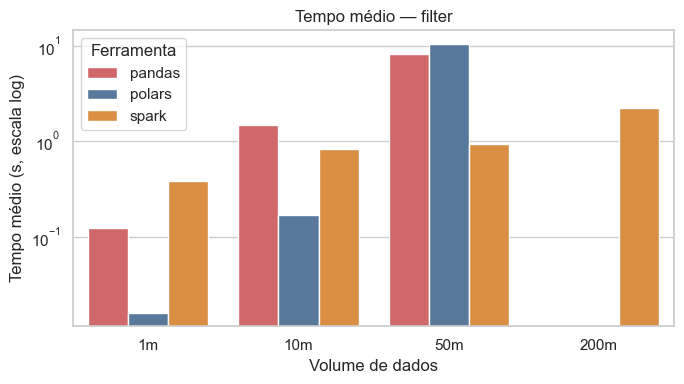

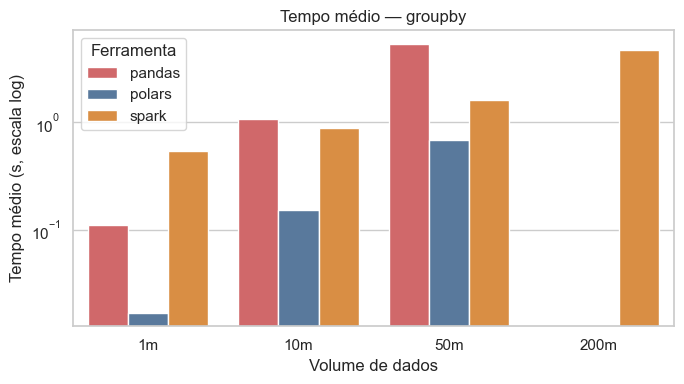

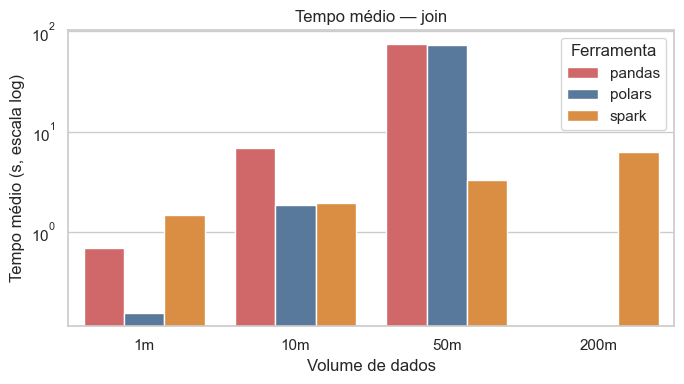

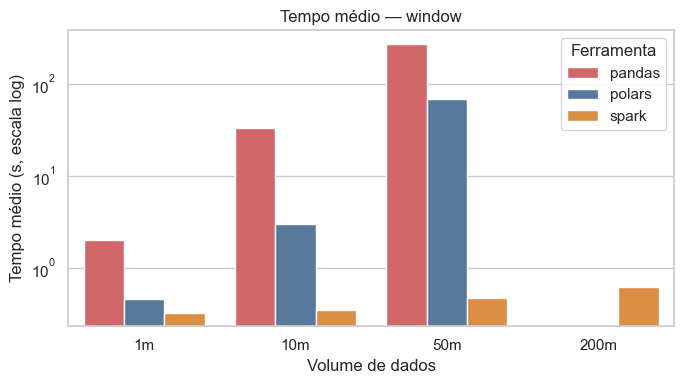

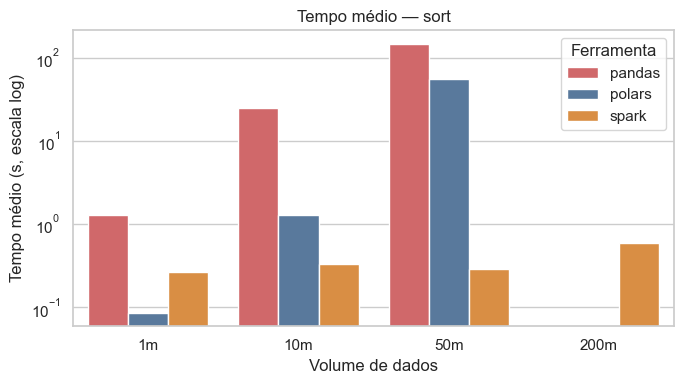

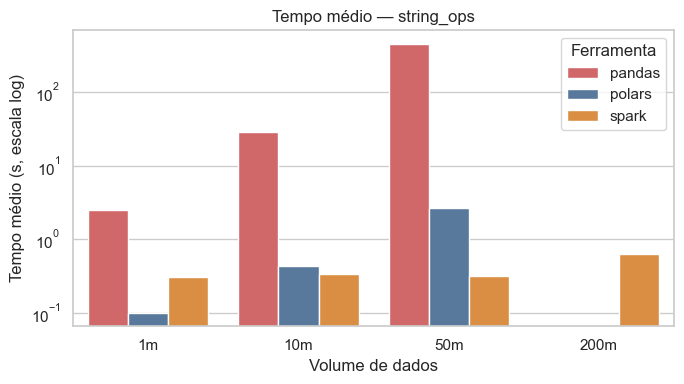

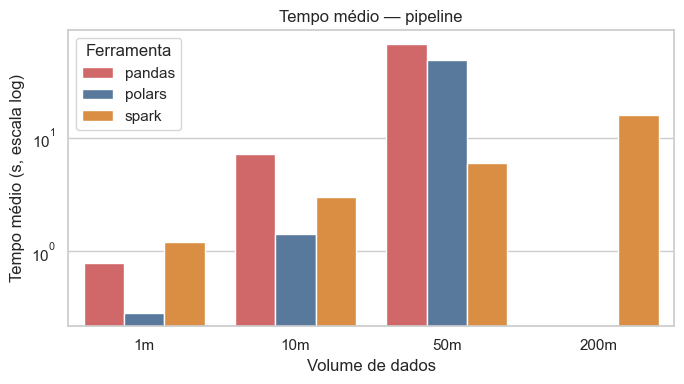

In [7]:
operations = df["operation"].unique()

for op in operations:
    subset = df[df["operation"] == op]

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(
        data=subset, x="dataset", y="mean_time_sec", hue="tool",
        order=dataset_order, hue_order=tool_order, palette=palette, ax=ax,
    )
    ax.set_yscale("log")  # escala log: os tempos variam em ordens de grandeza entre volumes
    ax.set_title(f"Tempo médio — {op}")
    ax.set_xlabel("Volume de dados")
    ax.set_ylabel("Tempo médio (s, escala log)")
    ax.legend(title="Ferramenta")
    plt.tight_layout()
    plt.savefig(Path("..") / "benchmark" / "results" / f"mean_time_{op}.png", dpi=150)
    plt.show()

## Memory usage x Volume 

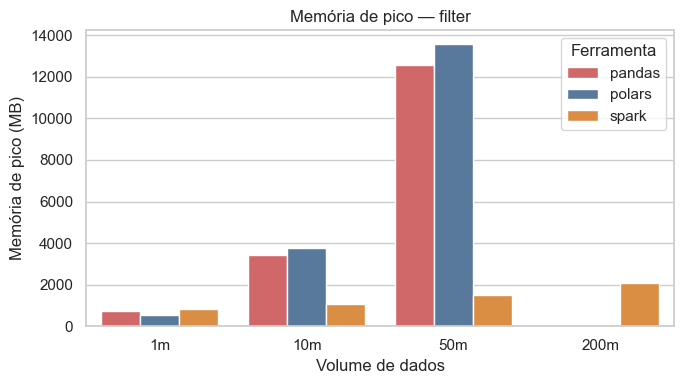

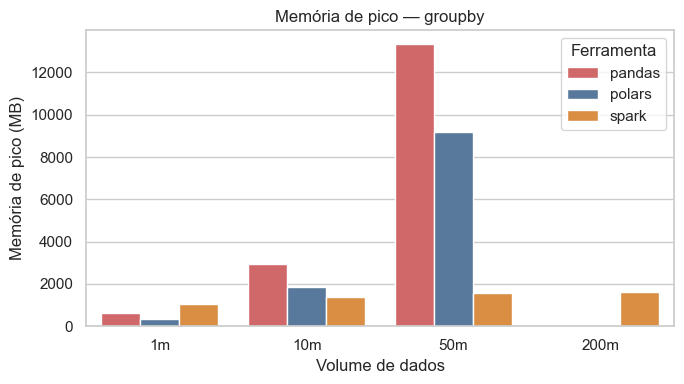

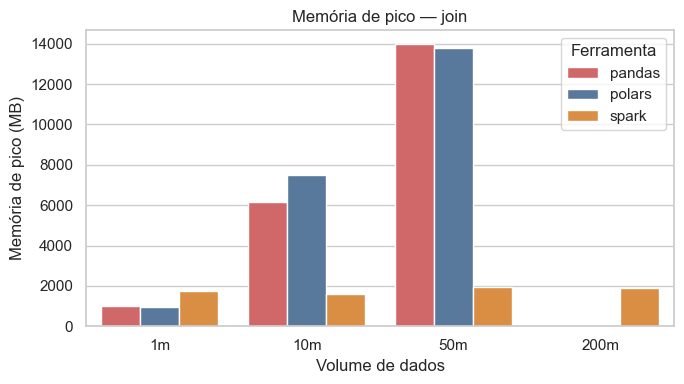

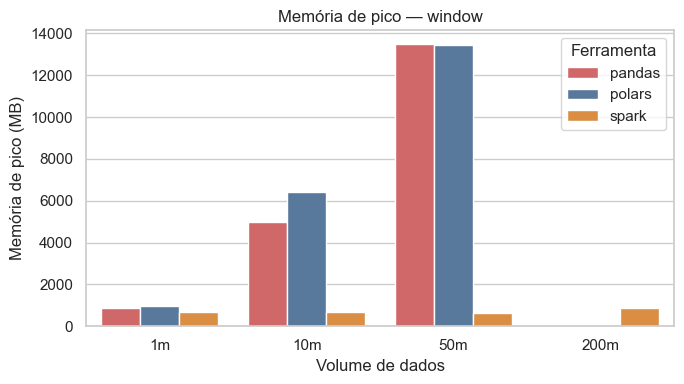

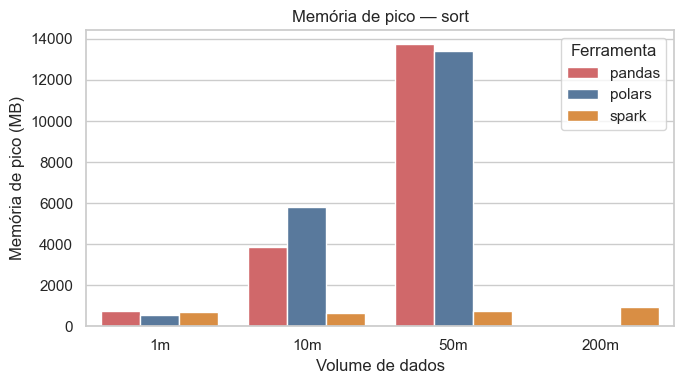

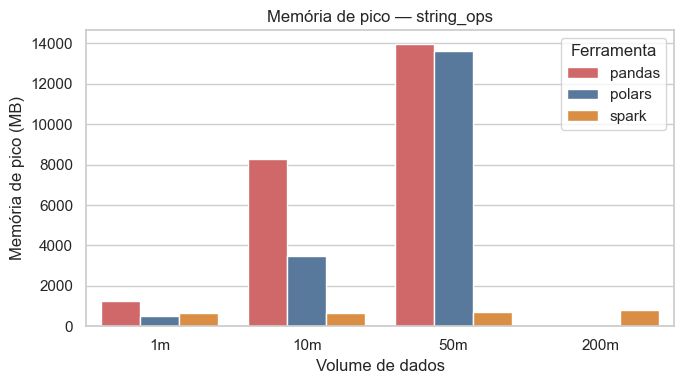

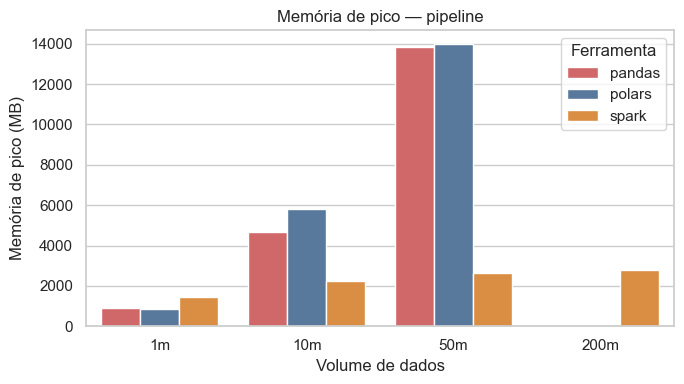

In [8]:
for op in operations:
    subset = df[df["operation"] == op]

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(
        data=subset, x="dataset", y="peak_memory_mb", hue="tool",
        order=dataset_order, hue_order=tool_order, palette=palette, ax=ax,
    )
    ax.set_title(f"Memória de pico — {op}")
    ax.set_xlabel("Volume de dados")
    ax.set_ylabel("Memória de pico (MB)")
    ax.legend(title="Ferramenta")
    plt.tight_layout()
    plt.savefig(Path("..") / "benchmark" / "results" / f"peak_memory_{op}.png", dpi=150)
    plt.show()

## Average time x Volume (aggregated across operations)

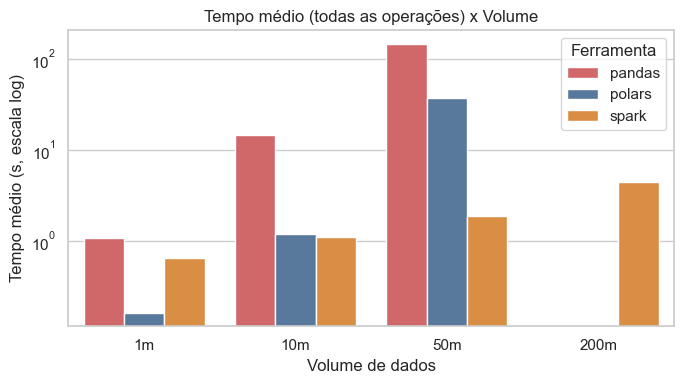

In [ ]:
avg_time = (
    df.groupby(["dataset", "tool"], observed=True)["mean_time_sec"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=avg_time, x="dataset", y="mean_time_sec", hue="tool",
    order=dataset_order, hue_order=tool_order, palette=palette, ax=ax,
)
ax.set_yscale("log")
ax.set_title("Tempo médio (todas as operações) x Volume")
ax.set_xlabel("Volume de dados")
ax.set_ylabel("Tempo médio (s, escala log)")
ax.legend(title="Ferramenta")
plt.tight_layout()
plt.savefig(Path("..") / "benchmark" / "results" / "avg_time_by_tool_dataset.png", dpi=150)
plt.show()

## Average memory use x Volume (aggregated across operations)

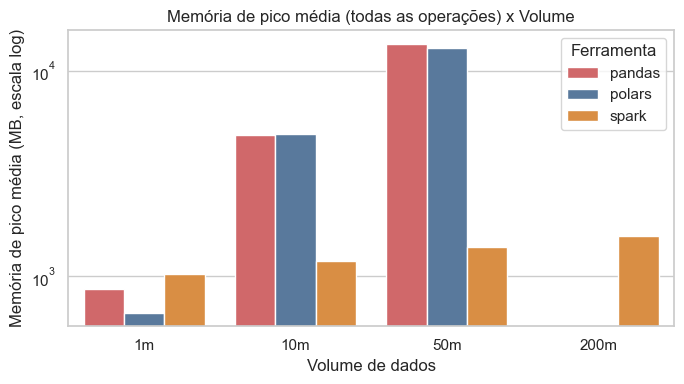

In [ ]:
avg_memory = (
    df.groupby(["dataset", "tool"], observed=True)["peak_memory_mb"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=avg_memory, x="dataset", y="peak_memory_mb", hue="tool",
    order=dataset_order, hue_order=tool_order, palette=palette, ax=ax,
)
ax.set_yscale("log")

ax.set_title("Memória de pico média (todas as operações) x Volume")
ax.set_xlabel("Volume de dados")
ax.set_ylabel("Memória de pico média (MB, escala log)")
ax.legend(title="Ferramenta")
plt.tight_layout()
plt.savefig(Path("..") / "benchmark" / "results" / "avg_memory_by_tool_dataset.png", dpi=150)
plt.show()